Beginning is the same as with corporate actions.
Only the returns with corporate actions are removed.

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import norm

df = pd.read_csv("data/sp500_data_from_2010.csv", parse_dates=["Date"])

df

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2010-01-04,A,22.453505,22.625179,22.267525,22.389128,19.810984,3.815561e+06
1,2010-01-04,AAPL,7.622500,7.660714,7.585000,7.643214,6.412382,4.937296e+08
2,2010-01-04,ABT,26.000362,26.177889,25.870815,26.129908,18.207748,1.082910e+07
3,2010-01-04,ACGL,7.978889,8.022222,7.972222,7.994444,7.601905,4.813200e+06
4,2010-01-04,ACN,41.520000,42.200001,41.500000,42.070000,31.227346,3.650100e+06
...,...,...,...,...,...,...,...,...
1737122,2026-04-17,XOM,144.860001,146.800003,141.970001,146.440002,146.440002,2.888650e+07
1737123,2026-04-17,YUM,159.690002,163.320007,159.690002,162.789993,162.789993,1.283400e+06
1737124,2026-04-17,ZBH,94.750000,96.559998,94.599998,94.779999,94.779999,1.567100e+06
1737125,2026-04-17,ZBRA,237.460007,240.830002,232.619995,234.429993,234.429993,1.069900e+06


In [2]:
# artihmetic returns
df = df.sort_values(["Ticker", "Date"])

df["previous_adj_close"] = (
    df.groupby("Ticker")["Adj Close"]
      .shift(1)
)


df["arithmetic_return"] = (
    ( df["Adj Close"] - df["previous_adj_close"] ) / df["previous_adj_close"]
)

# remove first observation per ticker
df= df.dropna(subset=["arithmetic_return"])

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return
424,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.595783,4.186031e+06,19.810984,-0.010863
848,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.526167,3.243779e+06,19.595783,-0.003553
1272,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.500853,3.095172e+06,19.526167,-0.001296
1696,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.494513,3.733918e+06,19.500853,-0.000325
2120,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.507172,4.781579e+06,19.494513,0.000649
...,...,...,...,...,...,...,...,...,...,...
1735430,2026-04-13,^GSPC,6806.470215,6887.000000,6790.020020,6886.240234,6886.240234,4.785840e+09,6816.890137,0.010173
1735854,2026-04-14,^GSPC,6910.200195,6969.419922,6905.169922,6967.379883,6967.379883,5.032380e+09,6886.240234,0.011783
1736278,2026-04-15,^GSPC,6978.169922,7026.240234,6967.129883,7022.950195,7022.950195,5.278610e+09,6967.379883,0.007976
1736702,2026-04-16,^GSPC,7037.779785,7051.229980,7008.520020,7041.279785,7041.279785,5.173650e+09,7022.950195,0.002610


In [3]:
# arithmetic returns in pourcent

df["arithmetic_return_%"] = df["arithmetic_return"] * 100

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%
424,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.595783,4.186031e+06,19.810984,-0.010863,-1.086268
848,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.526167,3.243779e+06,19.595783,-0.003553,-0.355262
1272,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.500853,3.095172e+06,19.526167,-0.001296,-0.129643
1696,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.494513,3.733918e+06,19.500853,-0.000325,-0.032512
2120,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.507172,4.781579e+06,19.494513,0.000649,0.064937
...,...,...,...,...,...,...,...,...,...,...,...
1735430,2026-04-13,^GSPC,6806.470215,6887.000000,6790.020020,6886.240234,6886.240234,4.785840e+09,6816.890137,0.010173,1.017327
1735854,2026-04-14,^GSPC,6910.200195,6969.419922,6905.169922,6967.379883,6967.379883,5.032380e+09,6886.240234,0.011783,1.178287
1736278,2026-04-15,^GSPC,6978.169922,7026.240234,6967.129883,7022.950195,7022.950195,5.278610e+09,6967.379883,0.007976,0.797578
1736702,2026-04-16,^GSPC,7037.779785,7051.229980,7008.520020,7041.279785,7041.279785,5.173650e+09,7022.950195,0.002610,0.260996


In [4]:
# Log returns
df = df.sort_values(["Ticker", "Date"])

df["log_return"] = (
    np.log(df["Adj Close"])
    - np.log(df["previous_adj_close"])
)

# remove first observation per ticker
df= df.dropna(subset=["log_return"])

display(df)

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return
424,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.595783,4.186031e+06,19.810984,-0.010863,-1.086268,-0.010922
848,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.526167,3.243779e+06,19.595783,-0.003553,-0.355262,-0.003559
1272,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.500853,3.095172e+06,19.526167,-0.001296,-0.129643,-0.001297
1696,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.494513,3.733918e+06,19.500853,-0.000325,-0.032512,-0.000325
2120,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.507172,4.781579e+06,19.494513,0.000649,0.064937,0.000649
...,...,...,...,...,...,...,...,...,...,...,...,...
1735430,2026-04-13,^GSPC,6806.470215,6887.000000,6790.020020,6886.240234,6886.240234,4.785840e+09,6816.890137,0.010173,1.017327,0.010122
1735854,2026-04-14,^GSPC,6910.200195,6969.419922,6905.169922,6967.379883,6967.379883,5.032380e+09,6886.240234,0.011783,1.178287,0.011714
1736278,2026-04-15,^GSPC,6978.169922,7026.240234,6967.129883,7022.950195,7022.950195,5.278610e+09,6967.379883,0.007976,0.797578,0.007944
1736702,2026-04-16,^GSPC,7037.779785,7051.229980,7008.520020,7041.279785,7041.279785,5.173650e+09,7022.950195,0.002610,0.260996,0.002607


In [5]:
# I merge the corporate action dataset here.
# Then I will keep only the lines where no splits happened.

actions = pd.read_csv("data/sp500_corporate_actions.csv")


actions["Date"] = pd.to_datetime(actions["Date"])

df["Date"] = pd.to_datetime(df["Date"])


df = df.merge(
    actions,
    on=["Date", "Ticker"],
    how="left"
)

df = df[
    (df["Stock Splits"].fillna(0) == 0) &
    (df["Dividends"].fillna(0) == 0)
]


display(df)


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits
0,2010-01-05,A,22.324751,22.331903,22.002861,22.145924,19.595783,4.186031e+06,19.810984,-0.010863,-1.086268,-0.010922,NaN,NaN,NaN
1,2010-01-06,A,22.067240,22.174536,22.002861,22.067240,19.526167,3.243779e+06,19.595783,-0.003553,-0.355262,-0.003559,NaN,NaN,NaN
2,2010-01-07,A,22.017166,22.045780,21.816881,22.038628,19.500853,3.095172e+06,19.526167,-0.001296,-0.129643,-0.001297,NaN,NaN,NaN
3,2010-01-08,A,21.917025,22.067240,21.745352,22.031473,19.494513,3.733918e+06,19.500853,-0.000325,-0.032512,-0.000325,NaN,NaN,NaN
4,2010-01-11,A,22.088697,22.210300,21.938484,22.045780,19.507172,4.781579e+06,19.494513,0.000649,0.064937,0.000649,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1736698,2026-04-13,^GSPC,6806.470215,6887.000000,6790.020020,6886.240234,6886.240234,4.785840e+09,6816.890137,0.010173,1.017327,0.010122,NaN,NaN,NaN
1736699,2026-04-14,^GSPC,6910.200195,6969.419922,6905.169922,6967.379883,6967.379883,5.032380e+09,6886.240234,0.011783,1.178287,0.011714,NaN,NaN,NaN
1736700,2026-04-15,^GSPC,6978.169922,7026.240234,6967.129883,7022.950195,7022.950195,5.278610e+09,6967.379883,0.007976,0.797578,0.007944,NaN,NaN,NaN
1736701,2026-04-16,^GSPC,7037.779785,7051.229980,7008.520020,7041.279785,7041.279785,5.173650e+09,7022.950195,0.002610,0.260996,0.002607,NaN,NaN,NaN


In [6]:
# remove ^GSP to not skew the distribution stats

df = df[df["Ticker"] != "^GSPC"]

In [7]:
ari_r = df["arithmetic_return"]

stats_summary = pd.Series({
    "count": ari_r.count(),
    "mean": ari_r.mean(),
    "std": ari_r.std(),
    "variance": ari_r.var(),
    "min": ari_r.min(),
    "1%": ari_r.quantile(0.01),
    "5%": ari_r.quantile(0.05),
    "25%": ari_r.quantile(0.25),
    "median": ari_r.median(),
    "75%": ari_r.quantile(0.75),
    "95%": ari_r.quantile(0.95),
    "99%": ari_r.quantile(0.99),
    "max": ari_r.max(),
    "skewness": ari_r.skew(),
    "kurtosis": ari_r.kurt()
})

stats_summary.apply(lambda x: f"{x:.6f}")

count       1710528.000000
mean              0.000691
std               0.019362
variance          0.000375
min              -0.538647
1%               -0.052116
5%               -0.027356
25%              -0.007924
median            0.000739
75%               0.009405
95%               0.028037
99%               0.053622
max               0.745932
skewness          0.180127
kurtosis         23.823084
dtype: object

In [8]:
log_r = df["log_return"]

stats_summary = pd.Series({
    "count": log_r.count(),
    "mean": log_r.mean(),
    "std": log_r.std(),
    "variance": log_r.var(),
    "min": log_r.min(),
    "1%": log_r.quantile(0.01),
    "5%": log_r.quantile(0.05),
    "25%": log_r.quantile(0.25),
    "median": log_r.median(),
    "75%": log_r.quantile(0.75),
    "95%": log_r.quantile(0.95),
    "99%": log_r.quantile(0.99),
    "max": log_r.max(),
    "skewness": log_r.skew(),
    "kurtosis": log_r.kurt()
})

stats_summary.apply(lambda x: f"{x:.6f}")


count       1710528.000000
mean              0.000503
std               0.019403
variance          0.000376
min              -0.773593
1%               -0.053523
5%               -0.027737
25%              -0.007955
median            0.000738
75%               0.009361
95%               0.027652
99%               0.052233
max               0.557289
skewness         -0.580858
kurtosis         26.745270
dtype: object

From these stats we see that the mean and median are really close to 0. The mean being slightly lower would indicate a slight left skew, confirmed by the skewness number.
THe standard deviation is about 1.9%. Which seems ok for daily equity volatility.
The minimum and maximum are really extreem compared to this volatility. Would that indicate "Fat Tails"?
The kurtosis is really high ( largely above 3 ) which indicates that this is a leptokurtic distribution. Which would also indicate "Fat Tails"?

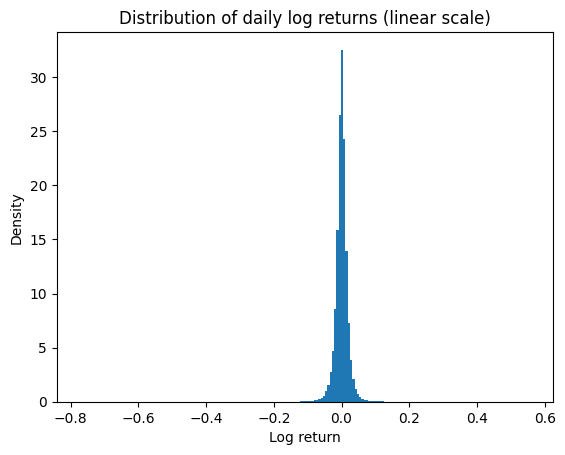

In [9]:
import matplotlib.pyplot as plt

returns = df["log_return"]

plt.hist(returns, bins=200, density=True)
plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Distribution of daily log returns (linear scale)")
plt.show()


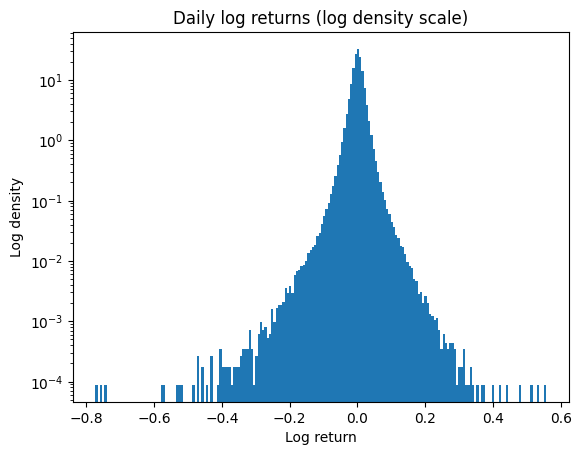

In [10]:
plt.hist(returns, bins=200, density=True)
plt.yscale("log")
plt.xlabel("Log return")
plt.ylabel("Log density")
plt.title("Daily log returns (log density scale)")
plt.show()


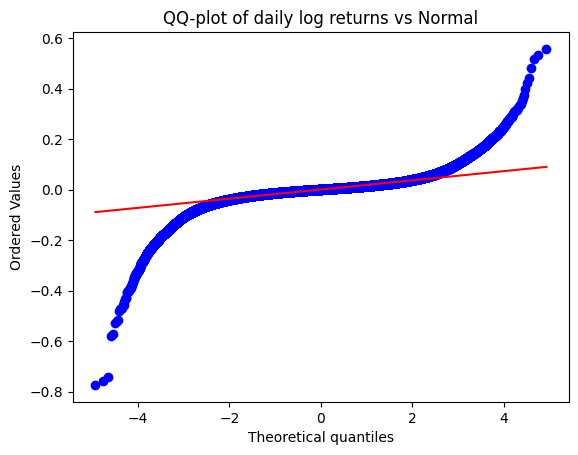

In [11]:
import scipy.stats as stats

stats.probplot(returns, dist="norm", plot=plt)
plt.title("QQ-plot of daily log returns vs Normal")
plt.show()


We overlay with a normal to see how it fits

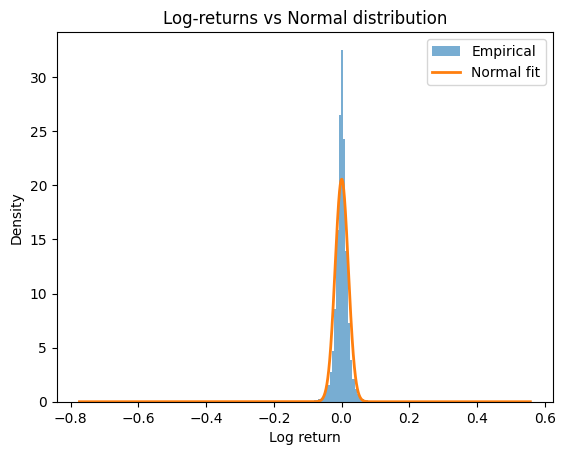

In [12]:
returns = df["log_return"].dropna()

mu = returns.mean()
sigma = returns.std()

x = np.linspace(returns.min(), returns.max(), 2000)

plt.hist(returns, bins=200, density=True, alpha=0.6, label="Empirical")
plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Log-returns vs Normal distribution")
plt.legend()
plt.show()

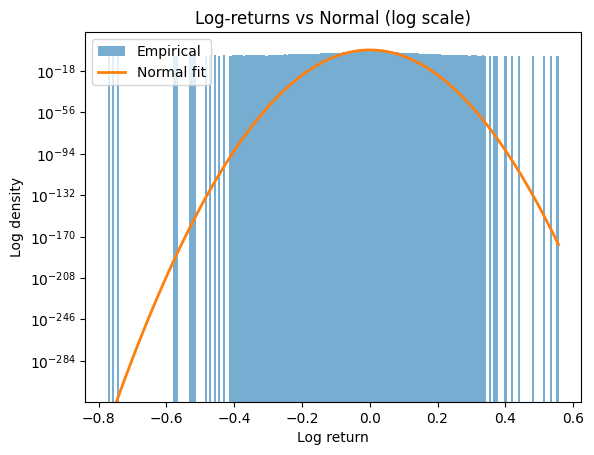

In [13]:

plt.hist(returns, bins=200, density=True, alpha=0.6, label="Empirical")
plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.yscale("log")
plt.xlabel("Log return")
plt.ylabel("Log density")
plt.title("Log-returns vs Normal (log scale)")
plt.legend()
plt.show()

My visualization fails because the normal is going way down in really low values... And the log scale follows

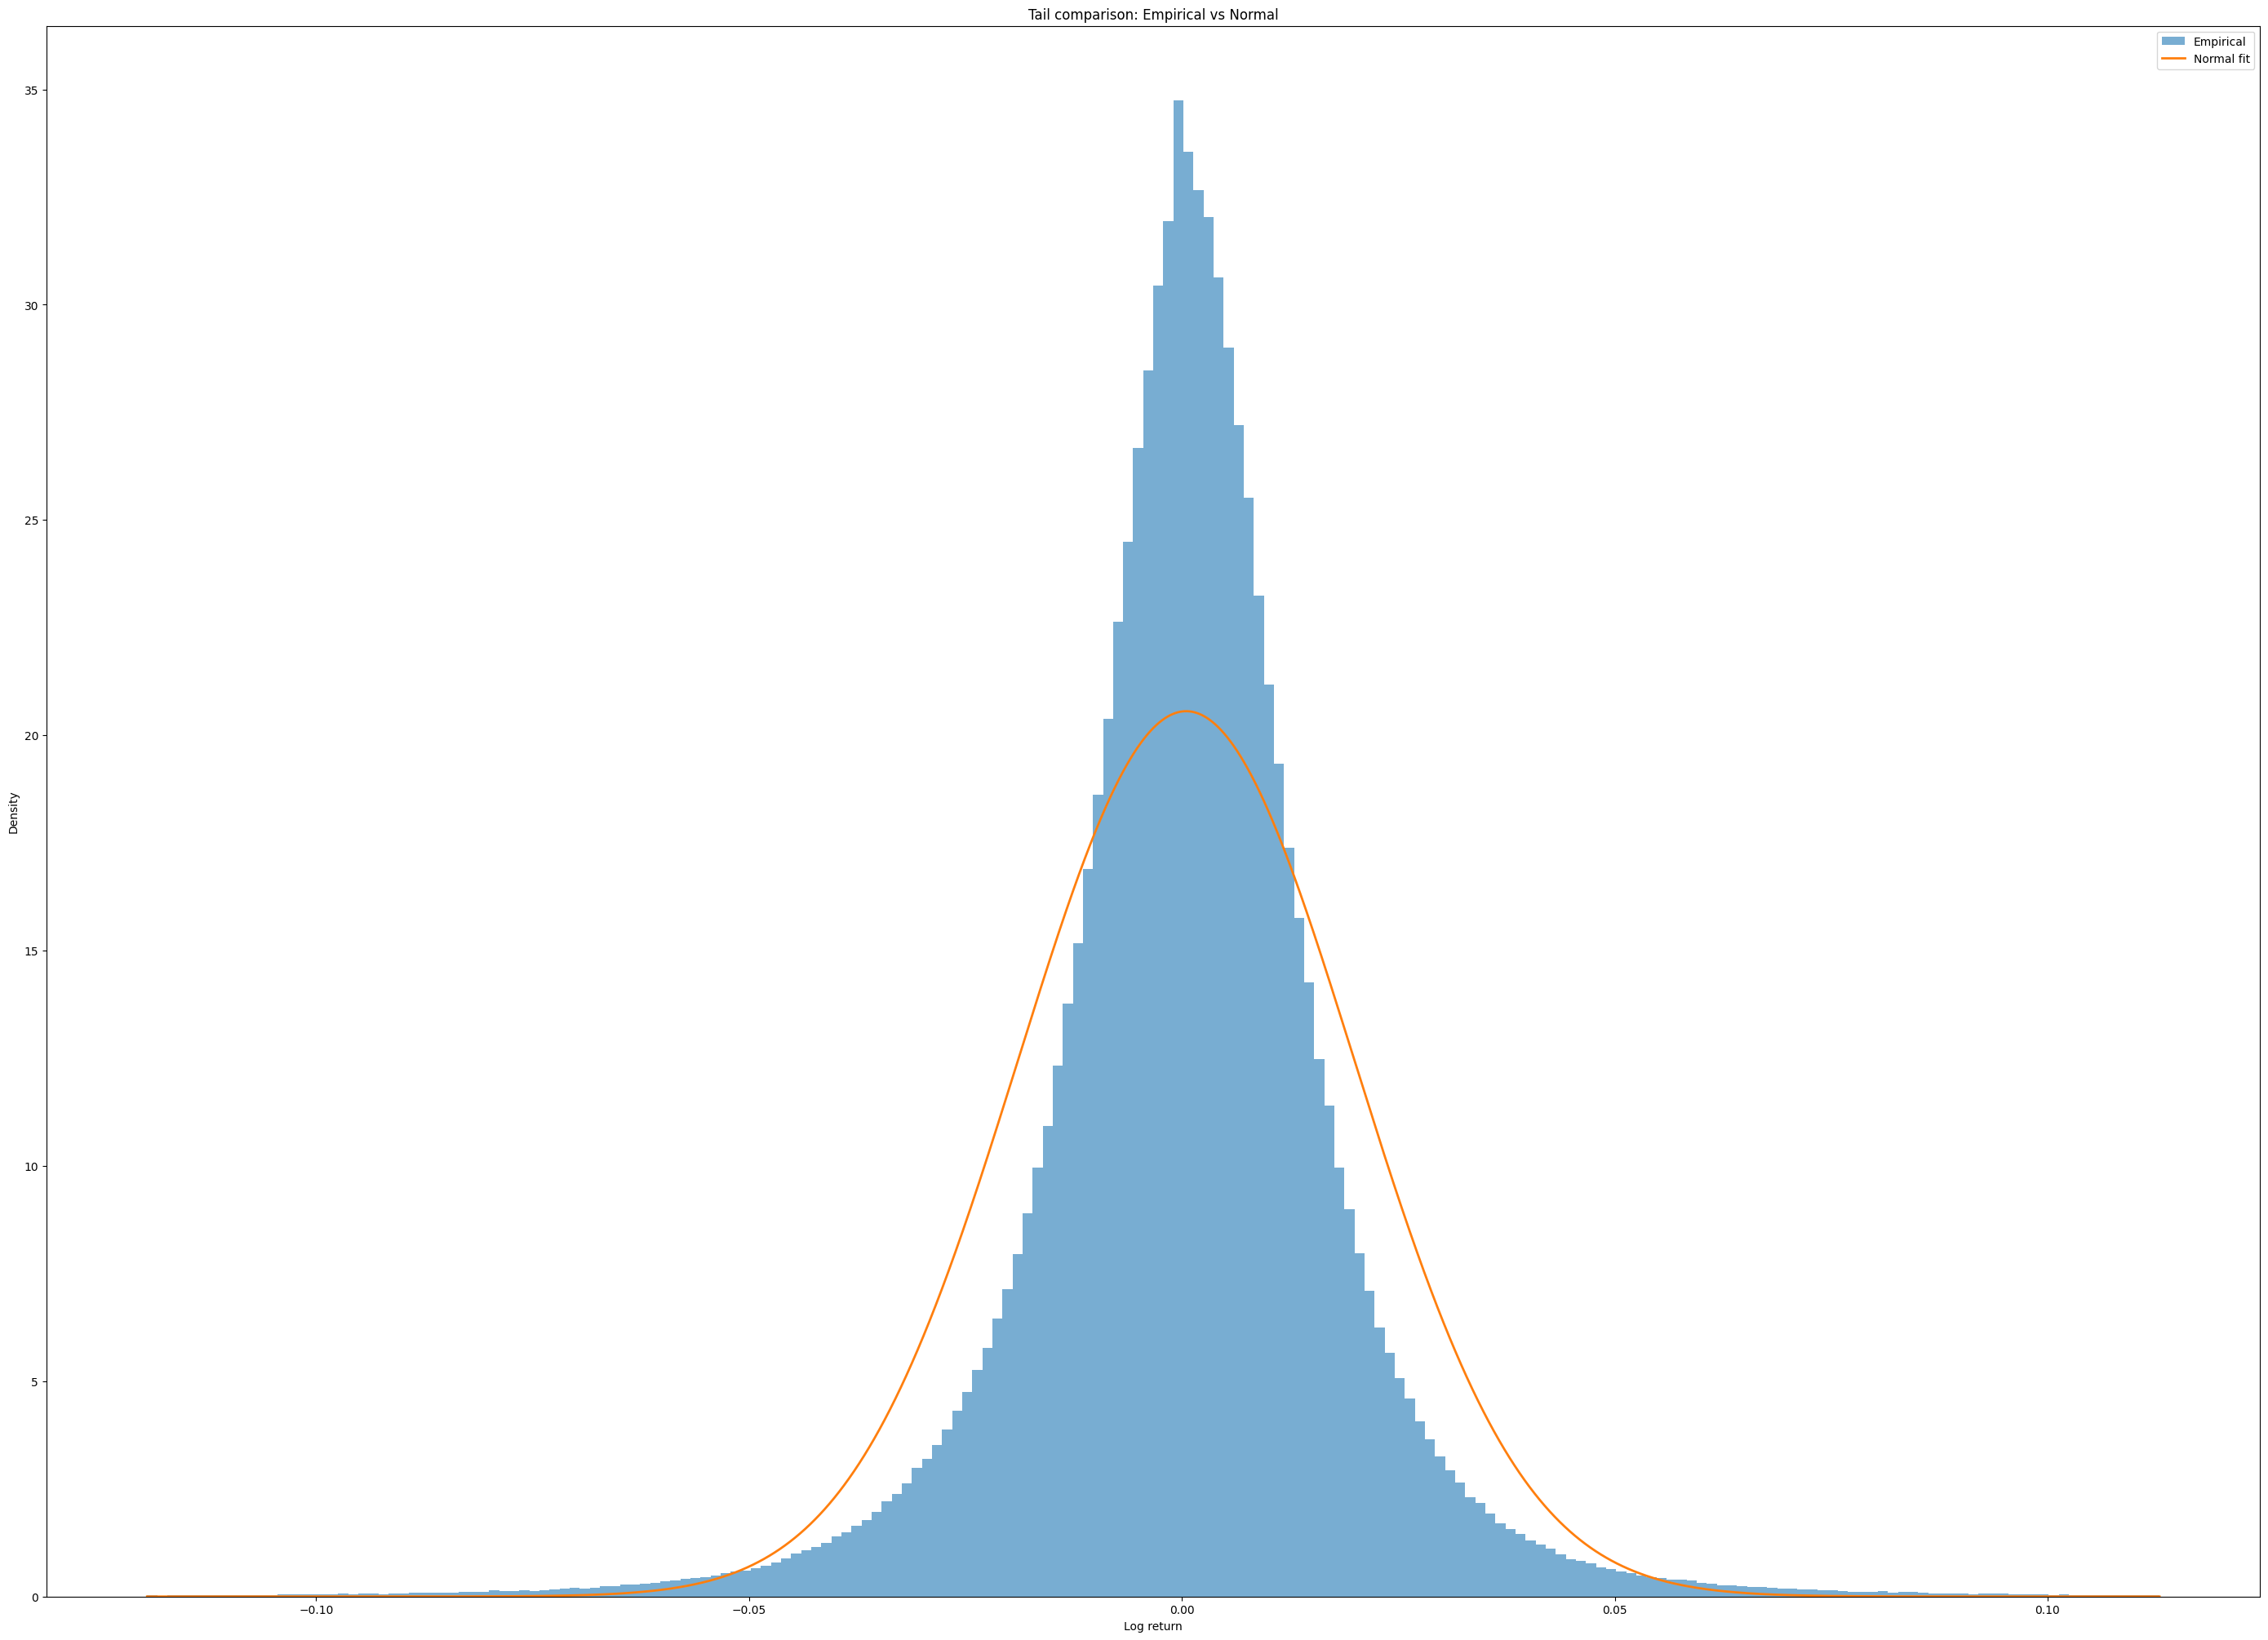

In [14]:
q_low, q_high = returns.quantile([0.001, 0.999])
q_low, q_high

x = np.linspace(q_low, q_high, 10000)
plt.figure(figsize=(35,25))
plt.hist(
    returns,
    bins=200,
    density=True,
    alpha=0.6,
    range=(q_low, q_high),
    label="Empirical"
)

plt.plot(x, norm.pdf(x, mu, sigma), lw=2, label="Normal fit")

plt.xlabel("Log return")
plt.ylabel("Density")
plt.title("Tail comparison: Empirical vs Normal")
plt.legend()

plt.show()

Now I will quantify the fat tails. First with Jarque-Bera and then with a simple ration of the empirical distribution over the normal.

In [15]:
from scipy.stats import jarque_bera

log_returns = df["log_return"].dropna()

jb_stat, jb_p = jarque_bera(log_returns)

print(f"JB statistic: {jb_stat:.2f}")
print(f"p-value: {jb_p:.2e}")


JB statistic: 51077412.92
p-value: 0.00e+00


In [16]:

q_emp = np.quantile(log_returns, [0.01, 0.05, 0.95, 0.99])
mu, sigma = log_returns.mean(), log_returns.std()

q_norm = norm.ppf([0.01, 0.05, 0.95, 0.99], mu, sigma)

tail_df = pd.DataFrame({
    "Empirical": q_emp,
    "Normal": q_norm,
    "Ratio": q_emp / q_norm
}, index=["1%", "5%", "95%", "99%"])

tail_df


,Empirical,Normal,Ratio
1%,-0.053523,-0.044636,1.199092
5%,-0.027737,-0.031413,0.882987
95%,0.027652,0.032419,0.852951
99%,0.052233,0.045642,1.144418


Now, I already did a skewness test (which is negative so leaning on the right with long tail on left) but I would like to now how the two tails differ.

In [17]:
# I try with the 1 percentile
q_low  = np.quantile(log_returns, 0.01)
q_high = np.quantile(log_returns, 0.99)

abs_ratio = abs(q_low) / abs(q_high)

print(q_low, q_high, abs_ratio)


-0.05352287349023206 0.05223343879415683 1.0246860004978167


ratio ≈ 1 → symmetric tails

ratio > 1 → left tail heavier

ratio < 1 → right tail heavier


In [18]:
# more systematic

levels = [0.001, 0.005, 0.01, 0.05]

tail_asym = []

for p in levels:
    q_l = np.quantile(log_returns, p)
    q_u = np.quantile(log_returns, 1 - p)
    tail_asym.append({
        "p": p,
        "left": q_l,
        "right": q_u,
        "abs_ratio": abs(q_l) / abs(q_u)
    })

pd.DataFrame(tail_asym)


,p,left,right,abs_ratio
0,0.001,-0.119527,0.112935,1.058370
1,0.005,-0.068579,0.066752,1.027364
2,0.010,-0.053523,0.052233,1.024686
3,0.050,-0.027737,0.027652,1.003097


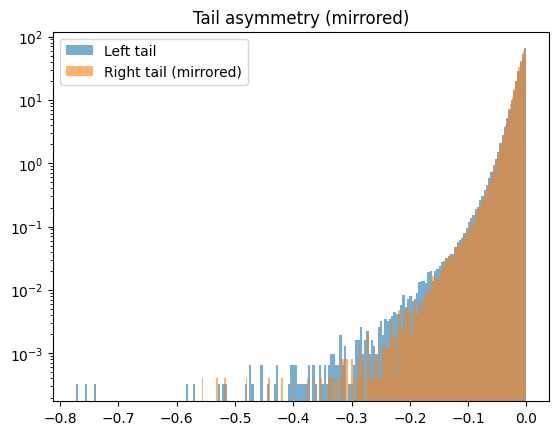

In [19]:
plt.hist(log_returns[log_returns < 0], bins=200, density=True, alpha=0.6, label="Left tail")
plt.hist(-log_returns[log_returns > 0], bins=200, density=True, alpha=0.6, label="Right tail (mirrored)")
plt.yscale("log")
plt.legend()
plt.title("Tail asymmetry (mirrored)")
plt.show()


Btw, the graph is in density mode, that's why it goes down to 10-3.

Now, I nee to check what are these outliers.

I could make a top 10 smallest returns and top 10 highest.

In [20]:
worst_10 = (
    df
    .sort_values(by="log_return", ascending=True)
    .head(10)
)

worst_10


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits
125440,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,-53.864746,-0.773593,NaN,NaN,NaN
724485,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,-53.140192,-0.758010,NaN,NaN,NaN
1214686,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,-52.359296,-0.741483,NaN,NaN,NaN
679819,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,-44.043751,-0.580600,NaN,NaN,NaN
1512521,2014-05-16,TKO,10.550000,11.930000,10.550000,11.270000,9.194171,40965100.0,16.259081,-0.434521,-43.452087,-0.570082,NaN,NaN,NaN
1403034,2018-10-04,SMCI,1.516000,1.516000,0.850000,1.260000,1.260000,125601000.0,2.140000,-0.411215,-41.121499,-0.529694,NaN,NaN,NaN
532047,2024-07-26,DXCM,66.000000,67.440002,62.340000,64.000000,64.000000,53914100.0,107.849998,-0.406583,-40.658321,-0.521858,NaN,NaN,NaN
360248,2025-07-02,CNC,37.340000,37.779999,33.759998,33.779999,33.779999,93566700.0,56.650002,-0.403707,-40.370701,-0.517023,NaN,NaN,NaN
1699544,2025-02-13,WST,243.839996,249.410004,197.009995,199.110001,198.409729,5219500.0,321.146515,-0.382183,-38.218315,-0.481563,NaN,NaN,NaN
1182207,2020-03-09,OKE,48.009998,48.009998,36.369999,38.099998,25.500282,18613800.0,40.967766,-0.377553,-37.755253,-0.474096,NaN,NaN,NaN


In [21]:
best_10 = (
    df
    .sort_values(by="log_return", ascending=False)
    .head(10)
)

best_10


,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits
1214693,2019-01-24,PCG,7.900000,14.500000,7.300000,13.950000,13.750663,8.253830e+07,7.875828,0.745932,74.593228,0.557289,NaN,NaN,NaN
1376093,2025-08-26,SATS,54.110001,55.189999,50.619999,50.869999,50.869999,4.657910e+07,29.879999,0.702477,70.247659,0.532084,NaN,NaN,NaN
226605,2015-04-13,BLDR,11.000000,11.740000,10.500000,11.570000,11.570000,1.737750e+07,6.900000,0.676812,67.681153,0.516894,NaN,NaN,NaN
1631034,2013-04-19,VRTX,81.550003,85.900002,80.099998,85.599998,85.599998,2.489500e+07,52.869999,0.619066,61.906564,0.481849,NaN,NaN,NaN
1630796,2012-05-07,VRTX,52.119999,58.750000,51.849998,58.119999,58.119999,4.021630e+07,37.410000,0.553595,55.359527,0.440572,NaN,NaN,NaN
91697,2016-04-22,AMD,3.190000,3.990000,3.180000,3.990000,3.990000,1.432653e+08,2.620000,0.522901,52.290083,0.420617,NaN,NaN,NaN
1376044,2025-06-16,SATS,24.270000,25.290001,23.870001,25.110001,25.110001,1.584490e+07,16.840000,0.491093,49.109266,0.399509,NaN,NaN,NaN
693042,2013-04-09,FSLR,27.139999,41.000000,26.760000,39.349998,39.349998,4.017120e+07,27.040001,0.455251,45.525137,0.375179,NaN,NaN,NaN
211624,2020-11-04,BIIB,253.199997,363.920013,251.750000,355.630005,355.630005,1.459150e+07,247.009995,0.439739,43.973933,0.364462,NaN,NaN,NaN
1127167,2013-01-24,NFLX,2.057000,2.131000,1.994571,2.098000,2.098000,1.188054e+09,1.475143,0.422235,42.223507,0.352230,NaN,NaN,NaN


In [22]:
outliers = pd.concat(
    {
        "Worst returns": worst_10,
        "Best returns": best_10
    }
)

outliers


Date Ticker        Open        High         Low  \
Worst returns 125440  2020-03-09    APA   13.420000   13.700000    9.320000   
              724485  2024-04-11     GL   98.480003   98.580002   38.950001   
              1214686 2019-01-14    PCG    9.210000    9.730000    7.780000   
              679819  2025-10-29   FISV   71.360001   76.650002   66.580002   
              1512521 2014-05-16    TKO   10.550000   11.930000   10.550000   
              1403034 2018-10-04   SMCI    1.516000    1.516000    0.850000   
              532047  2024-07-26   DXCM   66.000000   67.440002   62.340000   
              360248  2025-07-02    CNC   37.340000   37.779999   33.759998   
              1699544 2025-02-13    WST  243.839996  249.410004  197.009995   
              1182207 2020-03-09    OKE   48.009998   48.009998   36.369999   
Best returns  1214693 2019-01-24    PCG    7.900000   14.500000    7.300000   
              1376093 2025-08-26   SATS   54.110001   55.189999   50.619999   
              226605  2015-04-13   BLDR   11.000000   11.740000   10.500000   
              1631034 2013-04-19   VRTX   81.550003   85.900002   80.099998   
              1630796 2012-05-07   VRTX   52.119999   58.750000   51.849998   
              91697   2016-04-22    AMD    3.190000    3.990000    3.180000   
              1376044 2025-06-16   SATS   24.270000   25.290001   23.870001   
              693042  2013-04-09   FSLR   27.139999   41.000000   26.760000   
              211624  2020-11-04   BIIB  253.199997  363.920013  251.750000   
              1127167 2013-01-24   NFLX    2.057000    2.131000    1.994571   

                            Close   Adj Close        Volume  \
Worst returns 125440     9.550000    8.224354  2.807320e+07   
              724485    49.169998   48.298512  3.657750e+07   
              1214686    8.380000    8.260254  1.271988e+08   
              679819    70.599998   70.599998  1.034542e+08   
              1512521   11.270000    9.194171  4.096510e+07   
              1403034    1.260000    1.260000  1.256010e+08   
              532047    64.000000   64.000000  5.391410e+07   
              360248    33.779999   33.779999  9.356670e+07   
              1699544  199.110001  198.409729  5.219500e+06   
              1182207   38.099998   25.500282  1.861380e+07   
Best returns  1214693   13.950000   13.750663  8.253830e+07   
              1376093   50.869999   50.869999  4.657910e+07   
              226605    11.570000   11.570000  1.737750e+07   
              1631034   85.599998   85.599998  2.489500e+07   
              1630796   58.119999   58.119999  4.021630e+07   
              91697      3.990000    3.990000  1.432653e+08   
              1376044   25.110001   25.110001  1.584490e+07   
              693042    39.349998   39.349998  4.017120e+07   
              211624   355.630005  355.630005  1.459150e+07   
              1127167    2.098000    2.098000  1.188054e+09   

                       previous_adj_close  arithmetic_return  \
Worst returns 125440            17.826614          -0.538647   
              724485           103.070229          -0.531402   
              1214686           17.338648          -0.523593   
              679819           126.169998          -0.440438   
              1512521           16.259081          -0.434521   
              1403034            2.140000          -0.411215   
              532047           107.849998          -0.406583   
              360248            56.650002          -0.403707   
              1699544          321.146515          -0.382183   
              1182207           40.967766          -0.377553   
Best returns  1214693            7.875828           0.745932   
              1376093           29.879999           0.702477   
              226605             6.900000           0.676812   
              1631034           52.869999           0.619066   
              1630796           37.410000           0.553595   
              91697 

# Now I need to *try* and explain why there was these huge variation.

In [23]:
mu = df["log_return"].mean()
sigma = df["log_return"].std()

df["z_score_global"] = (df["log_return"] - mu) / sigma

In [24]:
import scipy.stats as stats

n_obs = len(df)

for k in [2, 3, 4, 5]:
    mask = df["z_score_global"].abs() > k
    
    empirical_pct = mask.mean()
    empirical_count = mask.sum()
    
    theoretical_pct = 2 * (1 - stats.norm.cdf(k))
    theoretical_count = theoretical_pct * n_obs
    
    print(f"{k}σ -> "
          f"Empirical: {empirical_pct:.6f} "
          f"({empirical_count} obs) | "
          f"Normal: {theoretical_pct:.6f} "
          f"(~{int(theoretical_count)} obs)")

2σ -> Empirical: 0.045477 (77790 obs) | Normal: 0.045500 (~77829 obs)
3σ -> Empirical: 0.015358 (26271 obs) | Normal: 0.002700 (~4618 obs)
4σ -> Empirical: 0.006769 (11579 obs) | Normal: 0.000063 (~108 obs)
5σ -> Empirical: 0.003474 (5943 obs) | Normal: 0.000001 (~0 obs)


In [25]:
# let's put a threshold at 4 sigma

# 1 Extract extreme observations
extreme_returns_std = df[df["z_score_global"].abs() > 4].copy()

print(f"Actual Number of extreme observations at 4 sigma: {len(extreme_returns_std)}")

# 2 Optional: sort for readability
extreme_returns_std = extreme_returns_std.sort_values(
    by="log_return",
    key=lambda x: x.abs(),
    ascending=False
)

# 3 Persist to CSV
extreme_returns_std.to_csv("data/sp500_sigma_extremes.csv", index=False)

Actual Number of extreme observations at 4 sigma: 11579


In [26]:
# 1️Define threshold (top 1% absolute returns)
threshold = df["log_return"].abs().quantile(0.999)

print(f"Extreme threshold (99.9th percentile absolute return): {threshold:.6f}")

# 2️Create extreme flag
df["extreme"] = df["log_return"].abs() >= threshold

# 3️Extract extreme observations
extreme_returns = df[df["extreme"]].copy()

print(f"Number of extreme observations: {len(extreme_returns)}")

# 4️Optional: sort for readability
extreme_returns = extreme_returns.sort_values(
    by="log_return",
    key=lambda x: x.abs(),
    ascending=False
)

# 5️Persist to CSV
extreme_returns.to_csv("data/sp500_pct_extremes.csv", index=False)

Extreme threshold (99.9th percentile absolute return): 0.143192
Number of extreme observations: 1711
